# Hyperparameter Tuning with Optuna — Quick, Draw! ANN


**Dataset — Quick, Draw!**: Google's crowd-sourced doodle dataset with 345 categories. Each image is a 28×28 grayscale bitmap of a hand-drawn sketch. We use 10 animal classes with 2,000 samples each (20,000 total) — small enough to train fast on CPU, diverse enough to make the classification task interesting.


Run the cells top-to-bottom. Cells marked **TODO** are for you to complete.


## Step 1 — Imports, reproducibility & device

Import PyTorch (model + training), NumPy (data handling), and Matplotlib (plots).
We fix random seeds so runs are repeatable, and detect a GPU (training uses it automatically if present).

**Note:** on Colab, enable a GPU via *Runtime → Change runtime type → GPU* — the device line will then print `cuda` and training will be much faster.


In [ ]:
import numpy as np
import random
import os
import urllib.request

import torch
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.optim as optim

from sklearn.model_selection import train_test_split

import matplotlib.pyplot as plt

In [ ]:
# Fix random seeds so every run is reproducible.
# Optuna still explores different hyperparameters each trial, but the randomness
# *inside* training (weight initialisation, batch shuffling) stays fixed.
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [ ]:
# Check for GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cpu


## Step 2 — Download and load the Quick, Draw! data

**Quick, Draw!** is Google's open dataset of 50 million hand-drawn doodles across 345 categories.
Each sketch is stored as a flattened **28×28 = 784** grayscale bitmap, with pixel values in **[0, 255]**.

We download only the 10 animal classes we need (one `.npy` file per class, ~7 MB each).
The helper below caches the files locally so re-running the notebook doesn't re-download.


In [ ]:
classes = ['cat', 'dog', 'elephant', 'penguin', 'lion',
           'shark', 'butterfly', 'crab', 'owl', 'horse']

N_PER_CLASS = 2000   # samples per class — keeps training fast on CPU

def load_quickdraw(classes, n_per_class=N_PER_CLASS):
    """Download (once) and load Quick Draw .npy files for the given classes."""
    data, labels = [], []
    for i, cls in enumerate(classes):
        fname = f"{cls}.npy"
        if not os.path.exists(fname):
            url_name = cls.replace(' ', '%20')
            url = (f"https://storage.googleapis.com/quickdraw_dataset"
                   f"/full/numpy_bitmap/{url_name}.npy")
            print(f"Downloading {cls}...")
            urllib.request.urlretrieve(url, fname)
        arr = np.load(fname)[:n_per_class]
        data.append(arr)
        labels.extend([i] * len(arr))
        print(f"  {cls:12s}: {len(arr)} samples loaded")

    X = np.vstack(data) / 255.0   # scale pixels to [0, 1]
    y = np.array(labels)
    print(f"\nFinal dataset  : {X.shape}")
    print(f"Classes        : {len(classes)}")
    print(f"Input dim      : {X.shape[1]}  (28 x 28 flattened)")
    return X, y

X, y = load_quickdraw(classes)
images = X.reshape(-1, 28, 28)   # keep a 2-D copy for plotting

  cat         : 2000 samples loaded
  dog         : 2000 samples loaded
  elephant    : 2000 samples loaded
  penguin     : 2000 samples loaded
  lion        : 2000 samples loaded
  shark       : 2000 samples loaded
  butterfly   : 2000 samples loaded
  crab        : 2000 samples loaded
  owl         : 2000 samples loaded
  horse       : 2000 samples loaded

Final dataset  : (20000, 784)
Classes        : 10
Input dim      : 784  (28 x 28 flattened)


## Step 3 — Visualise the data

A sample grid showing 8 random doodles per class — so you know what the network will be learning to classify.


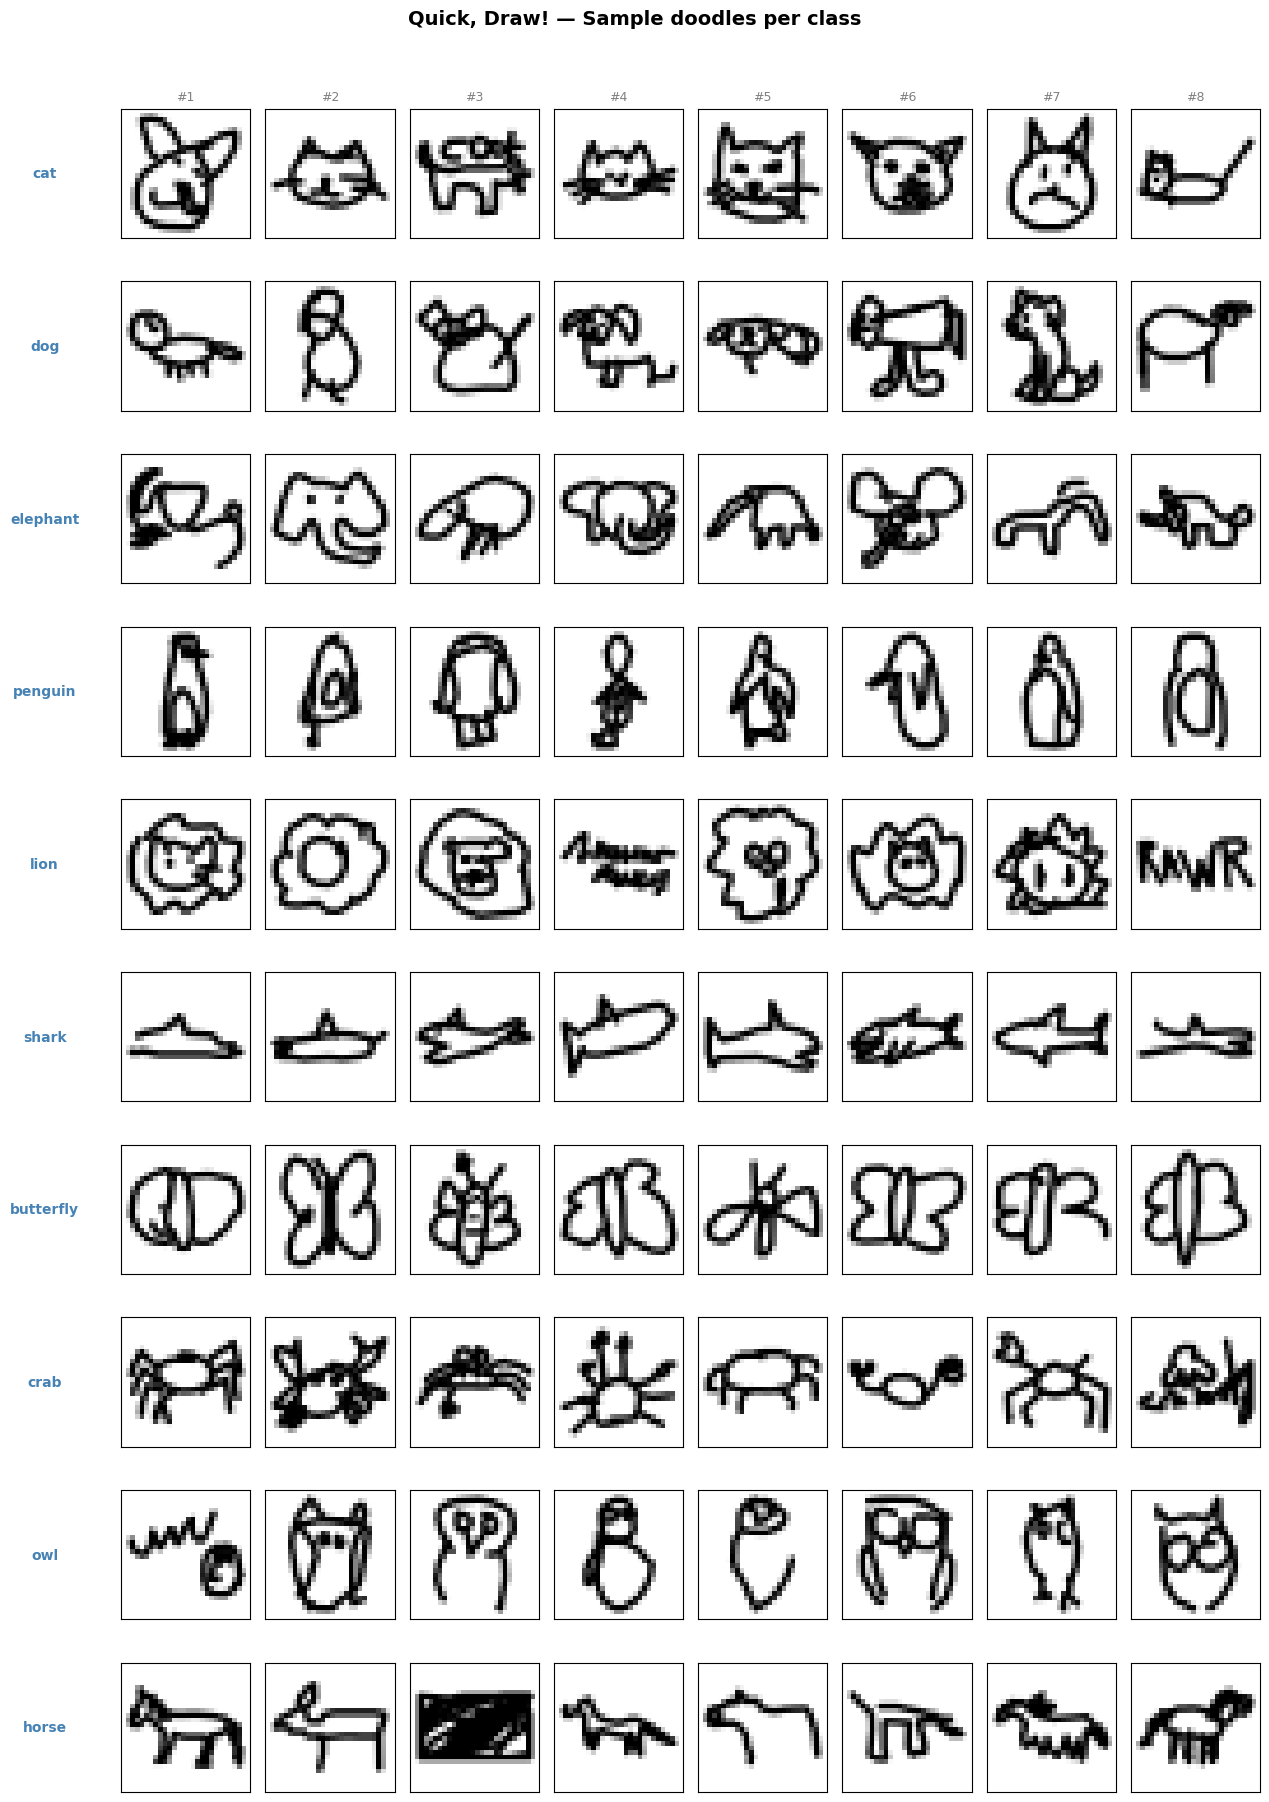

In [ ]:
# Sample grid — 8 random doodles per class
n_cols = 8
fig, axes = plt.subplots(len(classes), n_cols,
                          figsize=(n_cols * 1.6, len(classes) * 1.8))

for row, cls in enumerate(classes):
    class_images = images[y == row]
    idx = np.random.choice(len(class_images), n_cols, replace=False)
    for col in range(n_cols):
        ax = axes[row][col]
        ax.imshow(class_images[idx[col]], cmap='gray_r')
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(cls, fontsize=10, fontweight='bold',
                          rotation=0, labelpad=55, va='center', color='steelblue')
        if row == 0:
            ax.set_title(f"#{col+1}", fontsize=9, color='gray')

plt.suptitle("Quick, Draw! — Sample doodles per class",
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Step 4 — Preprocess **(TODO)**

Three things to do here:

1. **Train / test split** — use `train_test_split` with `stratify=y` so every class is represented in both splits.
2. **Scaling** — already done (`load_quickdraw` divides by 255).
3. **Wrap in a `Dataset`** — implement `CustomDataset` so a `DataLoader` can feed the model mini-batches.

> **Note:** the `DataLoader` is created *inside* the objective function (Step 6) — because `batch_size` is a hyperparameter Optuna will tune.


In [ ]:
# TODO: split X and y into training and test sets.
# Use test_size=0.2, random_state=SEED, and stratify=y.

X_train, X_test, y_train, y_test = None, None, None, None   # replace with your code

In [ ]:
class CustomDataset(Dataset):

    def __init__(self, features, labels):
        # TODO: convert features to a float32 tensor  →  self.features
        #       convert labels   to a long tensor     →  self.labels
        pass

    def __len__(self):
        # TODO: return the total number of samples
        pass

    def __getitem__(self, index):
        # TODO: return (feature_tensor, label_tensor) at position `index`
        pass

In [ ]:
# TODO: create train_dataset and test_dataset using CustomDataset
train_dataset = None   # replace with your code
test_dataset  = None   # replace with your code

In [ ]:
# Sanity check — should print (16000, 4000) for an 80/20 split of 20 000 samples
len(train_dataset), len(test_dataset)

## Step 5 — A parameterized network **(TODO)**

Rather than hard-coding one architecture, `MyNN` should be built from its constructor arguments:
`num_hidden_layers` (depth), `neurons_per_layer` (width), and `dropout_rate` (regularisation) —
so that Optuna can reshape the whole network just by changing numbers.

Each hidden block should follow the pattern:
**`Linear → BatchNorm1d → ReLU → Dropout`**, repeated `num_hidden_layers` times,
followed by one final `Linear` producing `output_dim` class scores (one per animal class).

Fill in all **TODO**s below.


In [ ]:
class MyNN(nn.Module):

    def __init__(self, input_dim, output_dim, num_hidden_layers, neurons_per_layer, dropout_rate):
        super().__init__()

        layers = []

        # TODO: loop `num_hidden_layers` times.
        # In each iteration append (in order):
        #   nn.Linear(input_dim, neurons_per_layer)
        #   nn.BatchNorm1d(neurons_per_layer)
        #   nn.ReLU()
        #   nn.Dropout(dropout_rate)
        # After each iteration set input_dim = neurons_per_layer
        # so the next block's input size matches the previous block's output.


        # TODO: append the final classification layer
        # nn.Linear(neurons_per_layer, output_dim)
        # — produces one score per class; no activation needed here
        #   because nn.CrossEntropyLoss applies softmax internally.


        # TODO: wrap `layers` in nn.Sequential and assign to self.model
        self.model = None

    def forward(self, x):
        # TODO: pass x through self.model and return the result
        return None

## Step 6 — The Optuna objective function **(TODO)**

Optuna calls this function once per **trial**. Your job:
1. **Suggest hyperparameters** using `trial.suggest_*` calls.
2. **Build DataLoaders** for train and test sets using the suggested `batch_size`.
3. **Instantiate the model**, loss function, and optimizer.
4. **Run the training loop** — forward pass → loss → backward → step.
5. Return test accuracy — the evaluation block is already written for you.

Use the table below for the search space:

| Hyperparameter | Optuna call | Suggested range / choices |
|---|---|---|
| Hidden layers | `suggest_int` | 1 – 4 |
| Neurons / layer | `suggest_int(step=32)` | 64 – 256 |
| Epochs | `suggest_int(step=10)` | 10 – 50 |
| Learning rate | `suggest_float(log=True)` | 1e-5 – 1e-1 |
| Dropout | `suggest_float(step=0.1)` | 0.1 – 0.5 |
| Batch size | `suggest_categorical` | 16, 32, 64, 128 |
| Optimizer | `suggest_categorical` | Adam, SGD, RMSprop |
| Weight decay | `suggest_float(log=True)` | 1e-5 – 1e-3 |

**Why `log=True`?** Learning rate and weight decay span orders of magnitude — log-scale sampling spends the search budget where it counts.


In [ ]:
def objective(trial):
    """Optuna calls this once per trial. Suggest hyperparameters, train, return test accuracy."""

    # ── TODO 1: suggest hyperparameters ──────────────────────────────────────
    # Replace each None with the correct trial.suggest_* call (see table above).
    num_hidden_layers = None   # TODO
    neurons_per_layer = None   # TODO
    epochs            = None   # TODO
    learning_rate     = None   # TODO
    dropout_rate      = None   # TODO
    batch_size        = None   # TODO
    optimizer_name    = None   # TODO
    weight_decay      = None   # TODO

    # ── TODO 2: create DataLoaders ───────────────────────────────────────────
    # Create train_loader and test_loader using train_dataset / test_dataset.
    # Use the suggested batch_size.
    # Hint: shuffle=True for training, shuffle=False for test.
    # Hint: pin_memory=(device.type == 'cuda') speeds up GPU transfers.
    pin = (device.type == 'cuda')

    train_loader = None   # TODO
    test_loader  = None   # TODO

    # ── TODO 3: instantiate model ─────────────────────────────────────────────
    # input_dim  = 784           (28 x 28 flattened pixels)
    # output_dim = len(classes)  (10 animal classes)
    # Use the suggested num_hidden_layers, neurons_per_layer, dropout_rate.
    # Move the model to `device`.

    input_dim  = None   # TODO
    output_dim = None   # TODO
    model      = None   # TODO — MyNN(...)
    # TODO: model.to(device)

    # ── TODO 4: loss function and optimizer ───────────────────────────────────
    # Use nn.CrossEntropyLoss() as the criterion.
    # Choose the optimizer based on optimizer_name ('Adam', 'SGD', 'RMSprop').
    # Pass lr=learning_rate and weight_decay=weight_decay to each.

    criterion = None   # TODO

    # TODO: if / elif / else block to assign optimizer based on optimizer_name
    optimizer = None   # TODO

    # ── TODO 5: training loop ─────────────────────────────────────────────────
    # Set model to train mode.
    # Loop over epochs, then over batches in train_loader.
    # Each batch: move data to device → forward pass → compute loss
    #             → zero_grad → backward → optimizer step.

    # TODO: model.train()
    # TODO: for epoch in range(epochs):
    #           for batch_features, batch_labels in train_loader:
    #               ...

    # ── evaluation — already written, do not change ───────────────────────────
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for batch_features, batch_labels in test_loader:
            batch_features, batch_labels = batch_features.to(device), batch_labels.to(device)
            outputs = model(batch_features)
            _, predicted = torch.max(outputs, 1)
            total   += batch_labels.shape[0]
            correct += (predicted == batch_labels).sum().item()

    return correct / total   # test accuracy — Optuna maximises this

## Step 7 — Create a study and run the search **(TODO)**

A **study** manages the entire optimisation run.

- `direction='maximize'` — Optuna will try to maximise the value returned by `objective` (test accuracy).
- `n_trials` — how many times to call `objective`. Start with **10** to confirm everything works, then raise to 20–30 for a better search.
- Optuna's default **TPE sampler** learns from past trials and focuses future ones on promising regions.

Fill in the two **TODO**s below.


In [ ]:
!pip install optuna -q

In [ ]:
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)   # suppress per-trial noise

# TODO: create a study that maximises the objective
study = None   # optuna.create_study(direction=...)

# TODO: run the search — call study.optimize with objective and n_trials=10
# study.optimize(...)

## Step 8 — Inspect results & Optuna visualizations

Everything in this step is already written — just run the cells.


In [ ]:
# Best accuracy and winning hyperparameters
print(f"Best test accuracy : {study.best_value:.4f}  ({study.best_value * 100:.2f}%)")
print()
print("Best hyperparameters:")
for param, value in study.best_params.items():
    print(f"  {param:20s}: {value}")

In [ ]:
# Install plotly — required for Optuna's interactive plots
!pip install plotly -q

In [ ]:
from optuna.visualization import plot_optimization_history, plot_param_importances

# How best accuracy improved trial by trial
# — a rising curve means Optuna is learning where the good regions are
fig1 = plot_optimization_history(study)
fig1.show()

In [ ]:
# Which hyperparameters had the most impact on accuracy
# — tall bars = high importance; use this to narrow your search space next time
fig2 = plot_param_importances(study)
fig2.show()

## Key takeaways

- **Hyperparameters are searched, not learned** — Optuna handles this in a few lines of code.
- **The objective function is the contract:** take a `trial`, train a model, return a score. Everything else is ordinary PyTorch.
- **`trial.suggest_*` defines the search space** — the TPE sampler beats grid/random search for the same trial budget.
- `plot_optimization_history` shows whether more trials would still improve results.
- `plot_param_importances` tells you which knobs actually matter — focus future searches on those.

**Good luck!**
